# 07 · AutoEncoder (이상탐지 관점)

> 발상의 전환: 백오더는 0.67%뿐인 '드문 사건'이다. 그래서 분류 대신 **이상탐지**로 접근한다.
> 방법: **정상(No)으로만** AutoEncoder를 학습 -> 백오더(Yes)는 패턴이 달라
> 재구성이 잘 안 되고 **재구성오차가 커진다** -> 그 오차를 '이상점수'로 쓴다.
>
> AutoEncoder는 입력을 작은 잠재벡터로 압축(encoder)했다가 복원(decoder)하는 신경망이다.
> 많이 본 패턴은 잘 복원하고, 못 본 패턴은 복원 오차가 크다는 성질을 이용한다.

## 0. 환경 설정
가벼운 모델이라(인코더-디코더 MLP) 전체 데이터로 빠르게 학습한다(서브샘플 불필요).

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils import set_seed, compute_metrics, log_result, load_processed
set_seed(42)

PROJECT_ROOT = Path(r"C:\Users\Administrator\Desktop\딥러닝응용\TermProject")
OUT_DIR     = PROJECT_ROOT / "processed"
RESULTS_CSV = PROJECT_ROOT / "notebooks" / "results.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. 데이터 불러오기 + 정상만 분리
핵심: AutoEncoder는 **정상(No) 행으로만** 학습한다. 그래야 '정상 패턴'을 익히고,
백오더(Yes)를 만났을 때 어색해서 오차가 커진다.

In [2]:
train_df, val_df, test_df = load_processed(OUT_DIR)
TARGET = "went_on_backorder"
feature_cols = [c for c in train_df.columns if c != TARGET]

X_train = train_df[feature_cols].values.astype("float32")
y_train = train_df[TARGET].values.astype("float32")
X_val   = val_df[feature_cols].values.astype("float32")
y_val   = val_df[TARGET].values.astype("float32")

X_normal = X_train[y_train == 0]   # 정상(No)만
print("정상(No) 학습 행:", len(X_normal), " / 전체 train:", len(X_train))

정상(No) 학습 행: 1341254  / 전체 train: 1350288


## 2. AutoEncoder 모델
입력(33) -> 16 -> 8(잠재) -> 16 -> 33(복원). 가운데 8차원으로 좁혀서 핵심만 남기고 복원하게 한다.

In [3]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

## 3. 학습 / 이상점수 함수
- 학습: 입력을 그대로 복원하도록 MSE(평균제곱오차)를 줄인다(정답 라벨 안 씀 = 비지도).
- 이상점수: 한 행의 재구성오차(평균제곱오차)가 클수록 '이상(백오더 의심)'.

In [4]:
def train_ae(model, X, epochs=15, lr=1e-3, batch_size=4096):
    model = model.to(device)
    loader = DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        for (xb,) in loader:
            xb = xb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward()
            opt.step()
        print("  epoch", epoch + 1, "/", epochs, " loss", round(float(loss), 5))
    return model

def anomaly_score(model, X, batch_size=8192):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.from_numpy(X[i:i + batch_size]).to(device)
            err = ((model(xb) - xb) ** 2).mean(dim=1)   # 행별 재구성오차
            out.append(err.cpu().numpy())
    return np.concatenate(out)

## 4. 학습 (정상만, 전체 데이터)

In [5]:
set_seed(42)
ae = AutoEncoder(input_dim=len(feature_cols))
ae = train_ae(ae, X_normal, epochs=15)
print("AE 학습 완료")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4724\1116955926.py:14: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  print("  epoch", epoch + 1, "/", epochs, " loss", round(float(loss), 5))


  epoch 1 / 15  loss 0.32041
  epoch 2 / 15  loss 0.2241
  epoch 3 / 15  loss 0.14967
  epoch 4 / 15  loss 0.14169
  epoch 5 / 15  loss 0.1339
  epoch 6 / 15  loss 0.15708
  epoch 7 / 15  loss 0.14344
  epoch 8 / 15  loss 0.12889
  epoch 9 / 15  loss 0.11972
  epoch 10 / 15  loss 0.10772
  epoch 11 / 15  loss 0.11284
  epoch 12 / 15  loss 0.1022
  epoch 13 / 15  loss 0.10146
  epoch 14 / 15  loss 0.10651
  epoch 15 / 15  loss 0.12209
AE 학습 완료


## 5. 평가 + 기록
val 전체의 재구성오차를 이상점수로 본다.
- PR_AUC/ROC_AUC: 점수의 '순위'만 보므로 그대로 의미 있음(높을수록 좋다).
- Recall/Precision/F1: 이상점수는 확률이 아니라서 threshold 0.5는 임의값 -> 큰 의미 없음(진짜 threshold는 08번).
표 일관성을 위해 점수를 0~1로 정규화만 한다.

In [6]:
score_val = anomaly_score(ae, X_val)
s = (score_val - score_val.min()) / (score_val.max() - score_val.min() + 1e-9)
metrics = compute_metrics(y_val, s)
log_result("AE_anomaly", metrics, path=str(RESULTS_CSV))
print("AE_anomaly", metrics)

AE_anomaly {'PR_AUC': 0.025, 'ROC_AUC': 0.7028, 'Recall': 0.0, 'Precision': 0.0, 'F1': 0.0, 'threshold': 0.5}


## 6. 재구성오차 분포: 정상 vs 백오더
백오더(Yes)가 더 오른쪽(오차 큼)에 몰려 있으면 AE가 둘을 구분하고 있다는 뜻.

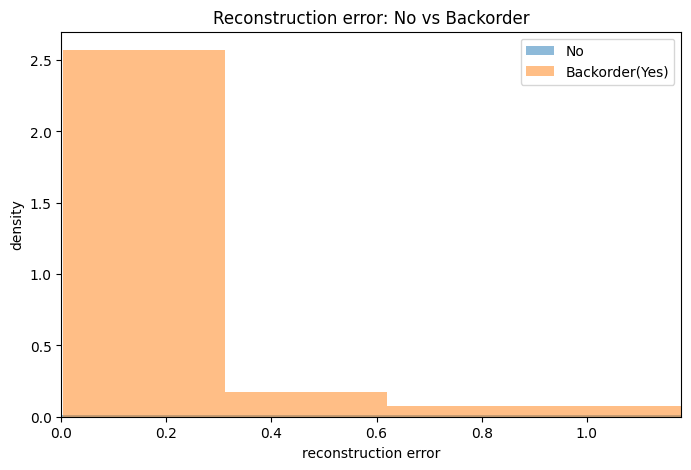

In [7]:
plt.figure(figsize=(8, 5))
plt.hist(score_val[y_val == 0], bins=60, alpha=0.5, density=True, label="No")
plt.hist(score_val[y_val == 1], bins=60, alpha=0.5, density=True, label="Backorder(Yes)")
plt.xlabel("reconstruction error")
plt.ylabel("density")
plt.legend()
plt.title("Reconstruction error: No vs Backorder")
plt.xlim(0, np.percentile(score_val, 99))   # 꼬리 잘라 보기 좋게
plt.show()

## 7. 결과 비교표

In [8]:
res = pd.read_csv(RESULTS_CSV)
res = res.drop_duplicates(subset="model", keep="last")
res = res.sort_values("PR_AUC", ascending=False)
res[["model", "PR_AUC", "ROC_AUC", "Recall", "Precision", "F1"]]

,model,PR_AUC,ROC_AUC,Recall,Precision,F1
11,XGBoost,0.2438,0.9618,0.8836,0.0598,0.1120
10,LightGBM,0.2237,0.9580,0.8907,0.0557,0.1048
2,MLP_3_focal,0.1927,0.9463,0.1983,0.3109,0.2422
3,MLP_4_focal_dropout,0.1859,0.9421,0.1301,0.3387,0.1880
0,MLP_1_plain_BCE,0.1859,0.9411,0.0217,0.4298,0.0413
1,MLP_2_weighted,0.1662,0.9469,0.8907,0.0451,0.0859
4,MLP_5_focal_drop_bn,0.1638,0.9443,0.0044,0.2041,0.0087
9,FT_Transformer,0.1446,0.9338,0.0713,0.2800,0.1136
5,MLP_6_undersample,0.1239,0.9328,0.7627,0.0625,0.1156
13,TabNet,0.0932,0.9193,0.9172,0.0241,0.0470


## 8. 저장 (분석용 결과 파일)

In [9]:
np.save(PROJECT_ROOT / "notebooks" / "ae_val_score.npy", s)
print("저장 완료: ae_val_score.npy")

저장 완료: ae_val_score.npy


---
### 정리
- AutoEncoder를 정상(No)으로만 학습 -> 재구성오차를 백오더 이상점수로 사용(비지도 이상탐지).
- 예상되는 정직한 결과: **라벨이 있는 상황에선 지도학습(트리/MLP)이 보통 비지도 AE보다 강하다.**
  AE의 PR_AUC가 낮게 나와도 실패가 아니라, "라벨이 있으면 지도학습이 유리"라는 비교 결론이다.
- 가치: 라벨이 거의 없는 현실 상황을 가정한 대안 접근 + 재구성오차 분포라는 직관적 해석.

다음: 08_Decision_Analysis(모든 모델 통합 + 비용 민감 threshold + 결론).